# Black Signal

В каждой спектрограмме закодирована последовательность из пяти цифр. Этот baseline читает PNG как одноканальное изображение, обучает небольшую CNN и формирует `submission.csv`.

При запуске ноутбук создаёт два файла:

- `fresh_checkpoint.pt` — веса после одной эпохи обучения в текущем запуске;
- `submission.csv` — предсказания для тестовой выборки.

Для инференса используется `datasets/solution/model.pt` — ваш заранее полностью обученный checkpoint, добавленный в workspace как отдельный набор данных.

In [302]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 11.8 MB/s  0:00:00a 0:00:01:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 12.7 MB/s  0:00:020.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [306]:
from pathlib import Path
import random
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
import copy
from sklearn.model_selection import train_test_split

SEED = 42
BATCH_SIZE = 32
TARGET_WIDTH = 384

DATA_DIR = Path("datasets")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

FRESH_CHECKPOINT_PATH = Path("fresh_checkpoint.pt")
FULL_CHECKPOINT_PATH = DATA_DIR / "solution" / "model.pt"
SUBMISSION_PATH = Path("submission.csv")

random.seed(SEED)
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Данные

Спектрограмма переводится в grayscale, разворачивается по частотной оси, нормализуется в диапазон `[0, 1]` и дополняется нулями или обрезается до ширины `384`. Колонка с именем PNG может называться `id` или `file`.

In [394]:
def image_path(directory: Path, image_id: str) -> Path:
    path = directory / str(image_id)
    if path.suffix.lower() != ".png":
        path = path.with_suffix(".png")
    return path


def load_spectrogram(path: Path) -> torch.Tensor:
    # print(path)
    image = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    image = image[::-1] / 255.0

    padding = max(0, TARGET_WIDTH - image.shape[1])
    image = np.pad(image, ((0, 0), (0, padding)))[:, :TARGET_WIDTH]
    image = np.ascontiguousarray(image)

    return torch.from_numpy(image).unsqueeze(0)


class SpectrogramDataset(Dataset):
    def __init__(self, table: pd.DataFrame, directory: Path, augment):
        self.table = table.reset_index(drop=True)
        self.directory = directory
        self.augment = augment
        self.image_column = "file" if "file" in table.columns else "id"

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, index: int):
        row = self.table.iloc[index]
        image = load_spectrogram(image_path(self.directory, row[self.image_column]))
        if self.augment:
            image = augment_spectrogram(image)
        target = torch.tensor([int(digit) for digit in row["code"]], dtype=torch.long)
        level = int(row["level"])
        return image, target, level


train_df = pd.read_csv(TRAIN_DIR / "labels.csv", dtype=str)
test_df = pd.read_csv(TEST_DIR / "labels.csv", dtype=str)
train_df["code"] = train_df["code"].str.zfill(5)

n = int(len(train_dataset) * 0.8)
indices = np.arange(len(train_dataset))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=train_df["level"]
)
train_dataset_aug = SpectrogramDataset(
    train_df,
    TRAIN_DIR,
    augment=True,
)

train_dataset_clean = SpectrogramDataset(
    train_df,
    TRAIN_DIR,
    augment=False,
)

train_subset = Subset(train_dataset_aug, train_idx)
val_subset = Subset(train_dataset_clean, val_idx)
# test_dataset = SpectrogramDataset(test_df, TEST_DIR)
tr_dl = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
va_dl = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
# t_dl = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_df)} samples")
print(f"Test:  {len(test_df)} samples")

Train: 360 samples
Test:  3 samples


In [396]:
len(train_subset)

288

In [184]:
train_df.level = train_df.level.astype(int)

In [ ]:
n_cols = 2
fig, ax = plt.subplots(5, n_cols, figsize=(10, 9))
for cls in range(1, 6):
    for i, row in enumerate(train_df[train_df.level == cls].file.sample(n_cols)):
        ax[cls-1, i].imshow(load_spectrogram(TRAIN_DIR / row).squeeze(0))

plt.show()
        
    

In [130]:
X = torch.tensor(train_df.file.apply(lambda file: load_spectrogram(TRAIN_DIR / file).numpy()).to_list())
X.shape

torch.Size([360, 1, 64, 384])

In [102]:
y = torch.tensor(train_df.code.apply(lambda code: [int(digit) for digit in code]).to_list())

## Модель и одна эпоха обучения

Модель выдаёт тензор размера `5 × 10`: для каждой из пяти позиций — логиты десяти цифр. Свежий checkpoint сохраняется сразу после одной эпохи.

In [430]:
def build_model() -> nn.Module:
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(4),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((4, 8)),
        nn.Flatten(),
        nn.Linear(32 * 4 * 8, 5 * 10),
        nn.Unflatten(1, (5, 10)),
    )


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    crit
) -> float:
    model.train()
    tl = 0.0
    tot = 0
    correct = {level: 0 for level in range(1, 6)}
    total = {level: 0 for level in range(1, 6)}
    
    for images, targets, levels in loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = crit(logits.reshape(-1, 10), targets.reshape(-1))
        # print(logits.argmax(2).shape)
        # print(targets.shape)
        tot += (logits.argmax(2) == targets).sum().item()
        for level in range(1, 6):
            mask = levels == level
            correct[level] += (logits.argmax(2)[mask] == targets[mask]).sum().item()
            total[level] += (levels==level).sum().item() * 5

        loss.backward()
        optimizer.step()
        tl += loss.item() * len(images)

    return tot / (len(loader.dataset) * 5), tl / len(loader.dataset), {level: (correct[level] / total[level]) for level in range(1, 6)}

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval()
    tl = 0.0; tot = 0
    correct = {level: 0 for level in range(1, 6)}
    total = {level: 0 for level in range(1, 6)}
    for xb, vb, levels in loader:
        logits = model(xb)
        loss = crit(logits.reshape(-1, 10), vb.reshape(-1))
        tot += (logits.argmax(2) == vb).sum().item()
        for level in range(1, 6):
            mask = levels == level
            correct[level] += (logits.argmax(2)[mask] == vb[mask]).sum().item()
            total[level] += (levels==level).sum().item() * 5

        tl += loss * len(xb)
    return tot / (len(loader.dataset) * 5), tl / len(loader.dataset), {level: (correct[level] / total[level]) for level in range(1, 6)}

In [416]:
def overfit_one(model, opt, tr_b, v_b, steps=301, debug=False):
    for i in range(steps):
        logits = model(tr_b)
        loss = crit(logits.reshape(-1, 10), v_b.reshape(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()
        acc = (logits.argmax(2) == v_b).sum().item() / (len(v_b) * 5)
        if debug:
            if i % 25 == 0: print(f"step={i}, acc={acc:.4f}")
        if acc == 1.0:
            if debug:
                print(f"step={i}, acc={acc:.4f}")
            break
    return acc

In [270]:
from models import *
model = DigitCNNv1()
print(f"parameters={sum([p.numel() for p in model.parameters()])}")
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
indices = torch.randperm(X.size(0))[:100]
overfit_one(model, opt, X[indices], y[indices], steps=500, debug=True)

parameters=100258
step=0, acc=0.12666666666666668
step=25, acc=0.8466666666666667
step=45, acc=1.0


1.0

Ok
ep=0, tr_acc=0.0972, va_acc=0.0861
ep=1, tr_acc=0.1222, va_acc=0.1000
ep=2, tr_acc=0.1111, va_acc=0.1000
ep=3, tr_acc=0.1222, va_acc=0.0889
ep=4, tr_acc=0.1236, va_acc=0.0889
ep=5, tr_acc=0.1229, va_acc=0.0889
ep=6, tr_acc=0.1299, va_acc=0.1056
ep=7, tr_acc=0.1556, va_acc=0.1583
ep=8, tr_acc=0.2042, va_acc=0.1583
ep=9, tr_acc=0.2139, va_acc=0.1583
ep=10, tr_acc=0.2257, va_acc=0.1694
ep=11, tr_acc=0.2437, va_acc=0.1750
ep=12, tr_acc=0.2424, va_acc=0.1611
ep=13, tr_acc=0.2299, va_acc=0.1722
ep=14, tr_acc=0.2611, va_acc=0.1722
ep=15, tr_acc=0.2535, va_acc=0.1917
ep=16, tr_acc=0.2514, va_acc=0.1861
ep=17, tr_acc=0.2715, va_acc=0.1722
ep=18, tr_acc=0.2785, va_acc=0.1889
ep=19, tr_acc=0.2778, va_acc=0.1833
ep=20, tr_acc=0.2875, va_acc=0.1806
ep=21, tr_acc=0.3028, va_acc=0.1861
ep=22, tr_acc=0.3014, va_acc=0.1778
ep=23, tr_acc=0.3201, va_acc=0.2000
ep=24, tr_acc=0.3326, va_acc=0.2056
ep=25, tr_acc=0.3306, va_acc=0.2111
ep=26, tr_acc=0.3479, va_acc=0.2222
ep=27, tr_acc=0.3521, va_acc=0.2083

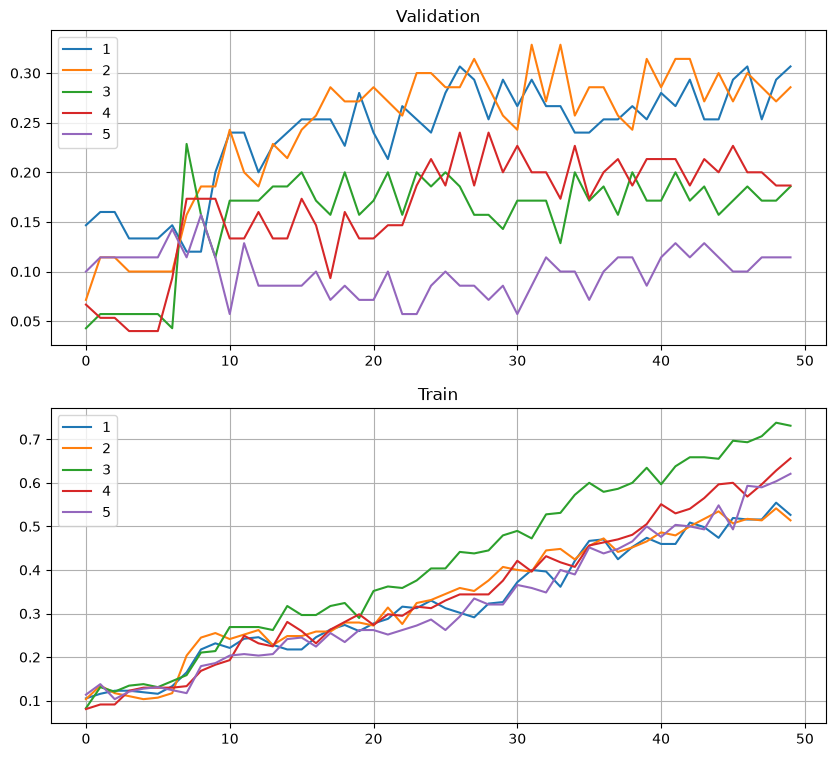

In [432]:
import importlib
import models
importlib.reload(models)
from models import *

NUM_EPOCHS = 50
model = PositionHeadsCNN()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
crit = nn.CrossEntropyLoss()
indices = torch.randperm(X.size(0))[:30]
# assert overfit_one(model, opt, X[indices], y[indices], steps=500, debug=True) == 1.0
print("Ok")
model = PositionHeadsCNN()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

PATIENCE = 50
LEARNING_RATE = 1e-3

best_acc = 0
bad_ep = 0
levels_va = {level: [] for level in range(1, 6)}
levels_tr = {level: [] for level in range(1, 6)}
for i in range(NUM_EPOCHS):
    tr_acc, tr_l, tr_lev_acc = train_one_epoch(model, tr_dl, opt, crit)
    va_acc, va_l, va_lev_acc = evaluate(model, va_dl, crit)
    print(f"ep={i}, tr_acc={tr_acc:.4f}, va_acc={va_acc:.4f}")
    for level in range(1, 6):
        levels_va[level].append(va_lev_acc[level])
        levels_tr[level].append(tr_lev_acc[level])
    if va_acc > best_acc:
        best_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())
        bad_ep = 0
    else:
        bad_ep += 1
        if bad_ep >= PATIENCE:
            break
model.load_state_dict(best_state)
print(f"best_acc={best_acc}")
fig, ax = plt.subplots(2, 1, figsize=(10, 9))
for name, values in levels_va.items():
    ax[0].plot(values, label=name)
ax[0].legend()
ax[0].grid()
ax[0].set_title("Validation")
for name, values in levels_tr.items():
    ax[1].plot(values, label=name)
ax[1].legend()
ax[1].set_title("Train")
ax[1].grid()
plt.show()

In [388]:
codes = np.array([
    [int(d) for d in code]
    for code in train_df["code"]
])

for position in range(5):
    counts = np.bincount(codes[:, position], minlength=10)
    majority_acc = counts.max() / len(codes)

    print(
        position,
        counts,
        "majority baseline:",
        majority_acc,
    )

0 [24 41 38 41 44 40 30 36 36 30] majority baseline: 0.12222222222222222
1 [33 32 45 27 30 42 31 42 39 39] majority baseline: 0.125
2 [31 40 29 34 37 33 37 35 43 41] majority baseline: 0.11944444444444445
3 [39 36 32 28 39 34 39 40 35 38] majority baseline: 0.1111111111111111
4 [24 37 31 44 37 41 31 36 41 38] majority baseline: 0.12222222222222222


In [389]:
def augment_spectrogram(image: torch.Tensor) -> torch.Tensor:
    image = image.clone()

    # Изменение интенсивности
    scale = torch.empty(1).uniform_(0.85, 1.15).item()
    image = (image * scale).clamp(0, 1)

    # Слабый шум
    if torch.rand(()) < 0.5:
        image = (
            image + 0.015 * torch.randn_like(image)
        ).clamp(0, 1)

    # Небольшой сдвиг по времени
    if torch.rand(()) < 0.5:
        shift = int(torch.randint(-12, 13, ()).item())
        image = torch.roll(image, shifts=shift, dims=-1)

        if shift > 0:
            image[..., :shift] = 0
        elif shift < 0:
            image[..., shift:] = 0

    return image

## Инференс и submission

Для итогового предсказания загружаются полностью обученные веса из `datasets/solution/model.pt`. Функция `predict` принимает путь к одному PNG и возвращает строку из пяти цифр.

In [10]:
model = build_model()
model.load_state_dict(torch.load(FULL_CHECKPOINT_PATH, map_location="cpu"))
model.eval()


@torch.inference_mode()
def predict(png_path: str | Path) -> str:
    image = load_spectrogram(Path(png_path)).unsqueeze(0)
    digits = model(image).argmax(dim=-1).squeeze(0).tolist()
    return "".join(map(str, digits))


test_image_column = "file" if "file" in test_df.columns else "id"
submission_ids = test_df["id"] if "id" in test_df.columns else test_df[test_image_column]

submission = pd.DataFrame(
    {
        "id": submission_ids,
        "code": [
            predict(image_path(TEST_DIR, image_id))
            for image_id in test_df[test_image_column]
        ],
    }
)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved: {SUBMISSION_PATH}")
submission.head()

Saved: submission.csv


,id,code
0,public_0000.png,42703
1,public_0001.png,42703
2,public_0002.png,42303
